<a href="https://colab.research.google.com/github/lawrancesahayasundar-tech/my_first_repo/blob/main/employee2_data_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Make results reproducible
np.random.seed(42)

# Create sample dataset
n = 200

df = pd.DataFrame({
    "CustomerID": range(1001,1001+n),
    "Age": np.random.randint(18,65,n),
    "Gender": np.random.choice(["Male","Female"],n),
    "City": np.random.choice(["Chennai","Madurai","Coimbatore","Trichy"],n),
    "Salary": np.random.randint(20000,100000,n),
    "Experience": np.random.randint(0,30,n),
    "Department": np.random.choice(["Sales","HR","IT","Finance"],n),
    "PerformanceScore": np.random.randint(40,100,n)
})

# Introduce missing values
df.loc[np.random.choice(df.index,20),"Salary"] = np.nan
df.loc[np.random.choice(df.index,15),"Age"] = np.nan

# Duplicate rows
df = pd.concat([df,df.iloc[:5]],ignore_index=True)

# Save dataset
df.to_csv("employee_data.csv",index=False)

print(df.head())
print("\nDataset Shape:",df.shape)

   CustomerID   Age  Gender        City   Salary  Experience Department  \
0        1001  56.0  Female     Chennai  82752.0          19         IT   
1        1002  46.0    Male     Madurai  76573.0          12      Sales   
2        1003  32.0  Female     Chennai  79101.0          27         HR   
3        1004  60.0    Male     Madurai  46646.0          15      Sales   
4        1005  25.0    Male  Coimbatore  43049.0          28         IT   

   PerformanceScore  
0                48  
1                56  
2                48  
3                50  
4                54  

Dataset Shape: (205, 8)


In [ ]:
import pandas as pd

df = pd.read_csv("employee_data.csv")

print(df.head())
print(df.dtypes)
print(df.shape)

   CustomerID   Age  Gender        City   Salary  Experience Department  \
0        1001  56.0  Female     Chennai  82752.0          19         IT   
1        1002  46.0    Male     Madurai  76573.0          12      Sales   
2        1003  32.0  Female     Chennai  79101.0          27         HR   
3        1004  60.0    Male     Madurai  46646.0          15      Sales   
4        1005  25.0    Male  Coimbatore  43049.0          28         IT   

   PerformanceScore  
0                48  
1                56  
2                48  
3                50  
4                54  
CustomerID            int64
Age                 float64
Gender               object
City                 object
Salary              float64
Experience            int64
Department           object
PerformanceScore      int64
dtype: object
(205, 8)


In [ ]:
null_count = df.isnull().sum()

null_percent = (df.isnull().sum()/df.shape[0])*100

print(pd.DataFrame({
    "Missing Count":null_count,
    "Missing %":null_percent
}))

                  Missing Count  Missing %
CustomerID                    0   0.000000
Age                          15   7.317073
Gender                        0   0.000000
City                          0   0.000000
Salary                       20   9.756098
Experience                    0   0.000000
Department                    0   0.000000
PerformanceScore              0   0.000000


In [ ]:
print(null_percent[null_percent>20])

Series([], dtype: float64)


In [ ]:
for col in df.select_dtypes(include="number").columns:
    if null_percent[col] < 20:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2001/3153477151.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:",duplicates)

df = df.drop_duplicates()

print(df.shape)

Duplicate Rows: 5
(200, 8)


In [ ]:
print(df.dtypes)

CustomerID            int64
Age                 float64
Gender               object
City                 object
Salary              float64
Experience            int64
Department           object
PerformanceScore      int64
dtype: object


In [ ]:
before = df.memory_usage(deep=True).sum()

df["Department"] = df["Department"].astype("category")

after = df.memory_usage(deep=True).sum()

print("Memory Before:",before)
print("Memory After :",after)

Memory Before: 42250
Memory After : 32279


In [ ]:
print(df.describe())

        CustomerID         Age        Salary  Experience  PerformanceScore
count   200.000000  200.000000    200.000000  200.000000        200.000000
mean   1100.500000   41.395000  58560.075000   14.375000         69.495000
std      57.879185   13.311459  21381.393008    8.900589         16.872861
min    1001.000000   18.000000  20412.000000    0.000000         40.000000
25%    1050.750000   31.000000  41520.500000    5.750000         53.000000
50%    1100.500000   42.000000  58088.000000   15.000000         71.500000
75%    1150.250000   53.000000  76794.250000   22.000000         83.000000
max    1200.000000   64.000000  99605.000000   29.000000         99.000000


In [ ]:
for col in df.select_dtypes(include="number").columns:
    print(col,df[col].skew())

CustomerID 0.0
Age -0.05455344204820039
Salary 0.12517166262828452
Experience -0.06825133086234039
PerformanceScore -0.0750567990344759


In [ ]:
skew = df.select_dtypes(include="number").skew()

print(skew)

print("Highest Skew Column:",skew.abs().idxmax())

CustomerID          0.000000
Age                -0.054553
Salary              0.125172
Experience         -0.068251
PerformanceScore   -0.075057
dtype: float64
Highest Skew Column: Salary


In [ ]:
Q1=df["Salary"].quantile(0.25)

Q3=df["Salary"].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=((df["Salary"]<lower)|(df["Salary"]>upper)).sum()

print(outliers)

0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

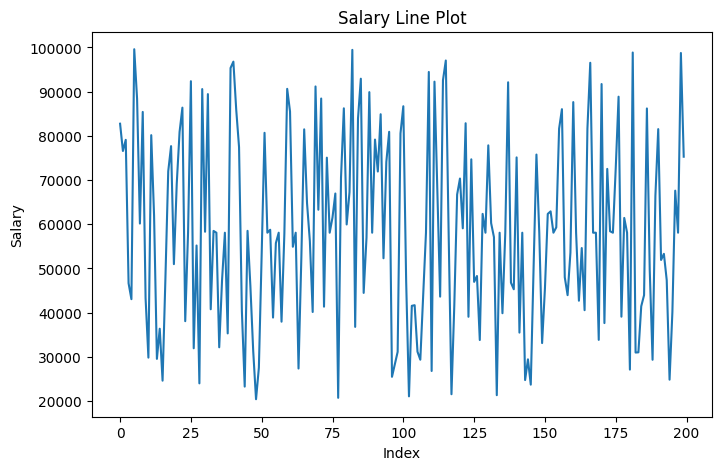

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df.index,df["Salary"])
plt.title("Salary Line Plot")
plt.xlabel("Index")
plt.ylabel("Salary")
plt.show()

/tmp/ipykernel_2001/194730654.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Department")["Salary"].mean().plot(kind="bar")


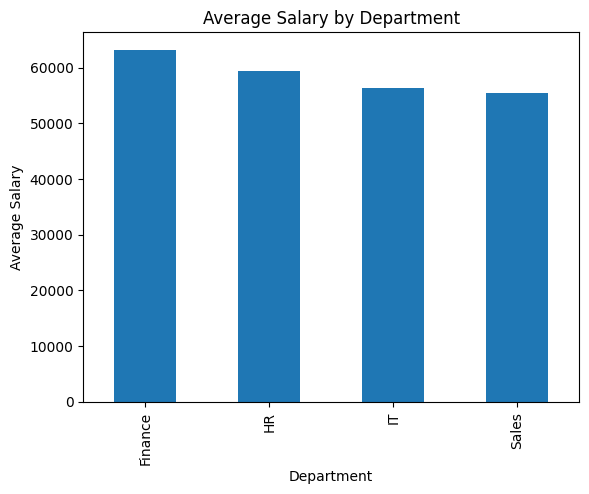

In [ ]:
df.groupby("Department")["Salary"].mean().plot(kind="bar")
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

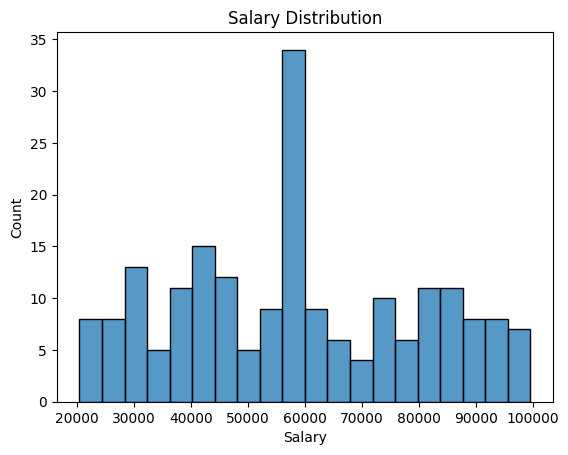

In [ ]:
sns.histplot(df["Salary"],bins=20)

plt.title("Salary Distribution")

plt.show()

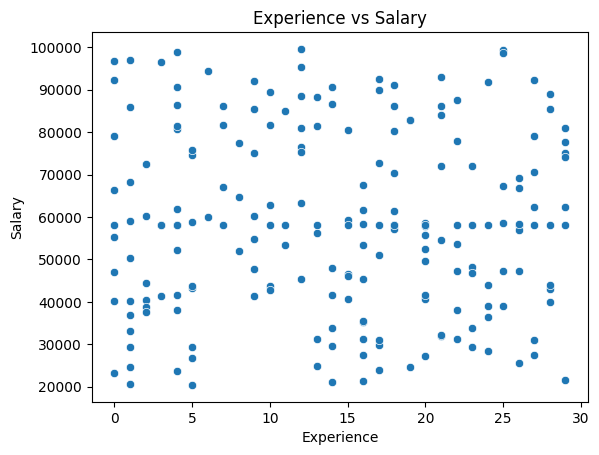

In [ ]:
sns.scatterplot(data=df,x="Experience",y="Salary")

plt.title("Experience vs Salary")

plt.show()

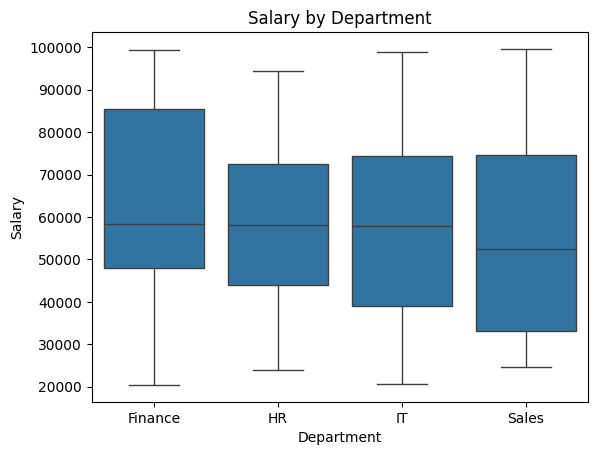

In [ ]:
sns.boxplot(data=df,x="Department",y="Salary")

plt.title("Salary by Department")

plt.show()

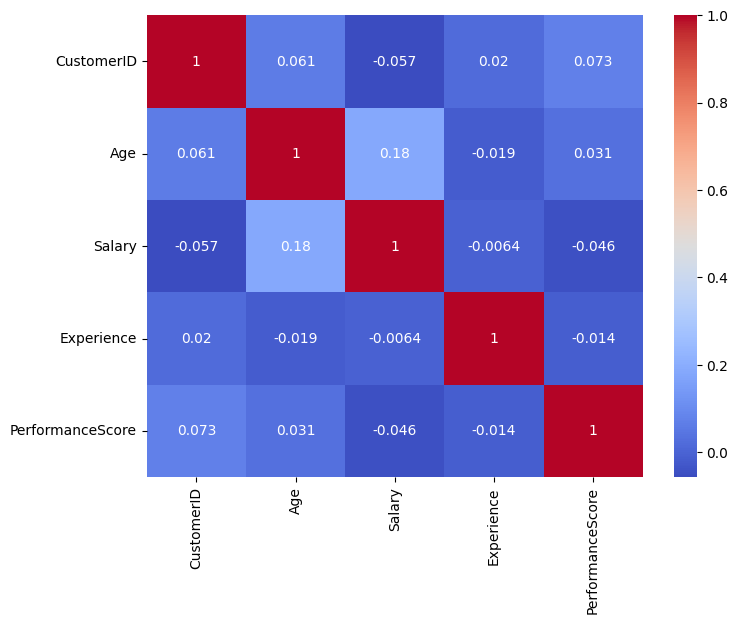

In [ ]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.show()

In [ ]:
skew=df.select_dtypes(include="number").skew().abs()

top2=skew.sort_values(ascending=False).head(2).index

for col in top2:
    print(col)
    print("Mean:",df[col].mean())
    print("Median:",df[col].median())

Salary
Mean: 58560.075
Median: 58088.0
PerformanceScore
Mean: 69.495
Median: 71.5


In [ ]:
pearson=df.corr(numeric_only=True)

spearman=df.corr(method="spearman",numeric_only=True)

print(pearson)

print(spearman)

difference=(spearman-pearson).abs()

print(difference)

                  CustomerID       Age    Salary  Experience  PerformanceScore
CustomerID          1.000000  0.060569 -0.057357    0.020411          0.073425
Age                 0.060569  1.000000  0.183152   -0.018604          0.031410
Salary             -0.057357  0.183152  1.000000   -0.006352         -0.045999
Experience          0.020411 -0.018604 -0.006352    1.000000         -0.013623
PerformanceScore    0.073425  0.031410 -0.045999   -0.013623          1.000000
                  CustomerID       Age    Salary  Experience  PerformanceScore
CustomerID          1.000000  0.071817 -0.055409    0.022121          0.073896
Age                 0.071817  1.000000  0.175039   -0.031475          0.039038
Salary             -0.055409  0.175039  1.000000   -0.004205         -0.046325
Experience          0.022121 -0.031475 -0.004205    1.000000         -0.013815
PerformanceScore    0.073896  0.039038 -0.046325   -0.013815          1.000000
                  CustomerID       Age    Salary  Ex

In [ ]:
result=df.groupby("Department")["Salary"].agg(["mean","std","count"])

print(result)

                    mean           std  count
Department                                   
Finance     63238.272727  22405.325385     44
HR          59455.105263  18846.226139     57
IT          56369.648148  22204.189134     54
Sales       55480.644444  22194.784204     45


/tmp/ipykernel_2001/1699624041.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result=df.groupby("Department")["Salary"].agg(["mean","std","count"])


In [ ]:
df.to_csv("cleaned_data.csv",index=False)

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("cleaned_data.csv")

print(df.head())

   CustomerID   Age  Gender        City   Salary  Experience Department  \
0        1001  56.0  Female     Chennai  82752.0          19         IT   
1        1002  46.0    Male     Madurai  76573.0          12      Sales   
2        1003  32.0  Female     Chennai  79101.0          27         HR   
3        1004  60.0    Male     Madurai  46646.0          15      Sales   
4        1005  25.0    Male  Coimbatore  43049.0          28         IT   

   PerformanceScore  
0                48  
1                56  
2                48  
3                50  
4                54  


In [27]:
y_reg = df["Salary"]

In [28]:
median_salary = df["Salary"].median()

df["HighSalary"] = (df["Salary"] > median_salary).astype(int)

y_clf = df["HighSalary"]

In [29]:
X = df.drop(["Salary","HighSalary"],axis=1)

In [30]:
X = pd.get_dummies(X,drop_first=True)

print(X.head())

   CustomerID   Age  Experience  PerformanceScore  Gender_Male  \
0        1001  56.0          19                48        False   
1        1002  46.0          12                56         True   
2        1003  32.0          27                48        False   
3        1004  60.0          15                50         True   
4        1005  25.0          28                54         True   

   City_Coimbatore  City_Madurai  City_Trichy  Department_HR  Department_IT  \
0            False         False        False          False           True   
1            False          True        False          False          False   
2            False         False        False           True          False   
3            False          True        False          False          False   
4             True         False        False          False           True   

   Department_Sales  
0             False  
1              True  
2             False  
3              True  
4             Fals

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
model = LinearRegression()

model.fit(X_train_scaled,y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test_scaled)

In [35]:
mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("MSE =",mse)

print("R2 =",r2)

MSE = 389267899.1652955
R2 = -0.04665650732748872


In [36]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

print(coef)

print()

print(coef.reindex(coef.Coefficient.abs().sort_values(ascending=False).index).head(3))

             Feature  Coefficient
0         CustomerID -2447.648671
1                Age  4383.414202
2         Experience -1165.344410
3   PerformanceScore -1091.000964
4        Gender_Male -2268.840060
5    City_Coimbatore  1395.973377
6       City_Madurai  -372.456320
7        City_Trichy  2801.897139
8      Department_HR   699.152529
9      Department_IT -1269.662825
10  Department_Sales -2831.027146

             Feature  Coefficient
1                Age  4383.414202
10  Department_Sales -2831.027146
7        City_Trichy  2801.897139


In [37]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled,y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge MSE")

print(mean_squared_error(y_test,ridge_pred))

print("Ridge R2")

print(r2_score(y_test,ridge_pred))

Ridge MSE
389361809.8732677
Ridge R2
-0.04690901274552495


In [38]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [40]:
print(y_train.value_counts())

HighSalary
0    92
1    68
Name: count, dtype: int64


In [44]:
model.fit(X_train_scaled,y_train)

LinearRegression()

In [49]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [50]:
pred = model.predict(X_test_scaled)

proba = model.predict_proba(X_test_scaled)[:,1]

In [51]:
print(confusion_matrix(y_test,pred))

[[12  7]
 [11 10]]


In [52]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.52      0.63      0.57        19
           1       0.59      0.48      0.53        21

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.56      0.55      0.55        40



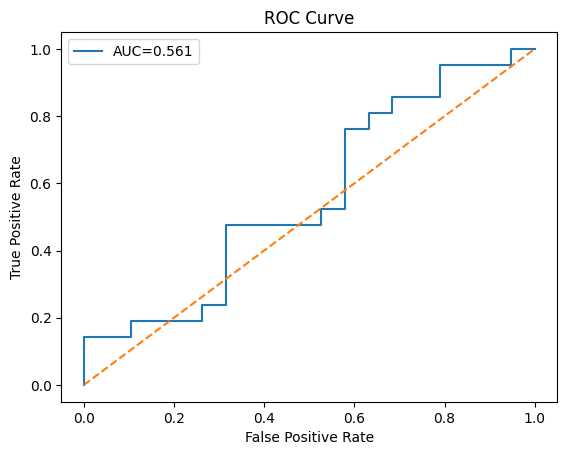

In [53]:
fpr,tpr,threshold = roc_curve(y_test,proba)

auc = roc_auc_score(y_test,proba)

plt.plot(fpr,tpr,label="AUC="+str(round(auc,3)))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [54]:
thresholds=[0.3,0.4,0.5,0.6,0.7]

for t in thresholds:

    prediction=(proba>=t).astype(int)

    p=precision_score(y_test,prediction)

    r=recall_score(y_test,prediction)

    f=f1_score(y_test,prediction)

    print(t,p,r,f)

0.3 0.5555555555555556 0.9523809523809523 0.7017543859649122
0.4 0.5862068965517241 0.8095238095238095 0.68
0.5 0.5882352941176471 0.47619047619047616 0.5263157894736842
0.6 0.4444444444444444 0.19047619047619047 0.26666666666666666
0.7 0.75 0.14285714285714285 0.24


In [55]:
model2=LogisticRegression(
    C=0.01,
    max_iter=1000
)

model2.fit(X_train_scaled,y_train)

pred2=model2.predict(X_test_scaled)

proba2=model2.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test,pred2))

print("AUC =",roc_auc_score(y_test,proba2))

              precision    recall  f1-score   support

           0       0.47      1.00      0.64        19
           1       0.00      0.00      0.00        21

    accuracy                           0.47        40
   macro avg       0.24      0.50      0.32        40
weighted avg       0.23      0.47      0.31        40

AUC = 0.5538847117794486


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
difference=[]

for i in range(500):

    idx=np.random.choice(
        len(y_test),
        len(y_test),
        replace=True
    )

    auc1=roc_auc_score(
        y_test.iloc[idx],
        proba[idx]
    )

    auc2=roc_auc_score(
        y_test.iloc[idx],
        proba2[idx]
    )

    difference.append(auc1-auc2)

print("Mean Difference =",np.mean(difference))

print(np.percentile(difference,[2.5,97.5]))

Mean Difference = 0.008152052249031623
[-0.03787879  0.06259348]
